# Legacy imaging — enriching_v3

**V3-01 — Notebook contract**

This notebook takes the output of the *linking* step plus AUTO annotations and produces:

- A full enriched annotation table (one row per ROI) for analysis
- A compact DB-upload subset (one row per ROI) for `public.imaging_roi_annotations`

**Inputs (from working/):**
- `seed_kits/legacy_wrangling/working/legacy_roi_structural_v7.csv`
- `seed_kits/legacy_wrangling/working/imaging_roi_annotations_AUTO_v6.csv`
- `seed_kits/legacy_wrangling/working/imaging_clutch_memberships_from_sheet_draft_v3.csv`
- `seed_kits/legacy_wrangling/working/imaging_injections.csv`
- `seed_kits/legacy_wrangling/working/roi_missing_parents_for_manual_mapping_v3.csv` (optional)

**Outputs (to working/):**
- `seed_kits/legacy_wrangling/working/legacy_imaging_annotations_v2.csv`
- `seed_kits/legacy_wrangling/working/2025-11-21-legacy_imaging_annotations_for_db_v2.csv`

Design goals:
- Strictly **one row per ROI** (by `roi_dir`) at every “final” stage
- All catalog lookups are table-driven (no slug/text magic)
- End-of-notebook QA loudly reports row explosions, duplicate `roi_dir`, and missing key fields

In [86]:
# V3-02 — imports and path config (no guessing)

from pathlib import Path

import pandas as pd

ROOT = Path("/Users/davekokel/Projects/carp_v2")
if not ROOT.exists():
    raise FileNotFoundError(f"Expected repo root at {ROOT} but it does not exist")

WORK = ROOT / "seed_kits" / "legacy_wrangling" / "working"
if not WORK.exists():
    raise FileNotFoundError(f"Expected WORK dir at {WORK} but it does not exist")

PATH_STRUCT_V7 = WORK / "legacy_roi_structural_v7.csv"
PATH_AUTO_V6 = WORK / "imaging_roi_annotations_AUTO_v6.csv"

PATH_CLUTCH = WORK / "imaging_clutch_memberships_from_sheet_draft_v3.csv"
PATH_INJECTIONS = WORK / "imaging_injections.csv"
PATH_PATCH_PARENTS = WORK / "roi_missing_parents_for_manual_mapping_v3.csv"

PATH_ANNOTATIONS_FULL = WORK / "legacy_imaging_annotations_v2.csv"
PATH_ANNOTATIONS_FOR_DB = WORK / "2025-11-21-legacy_imaging_annotations_for_db_v2.csv"

for path in [PATH_STRUCT_V7, PATH_AUTO_V6]:
    if not path.exists():
        raise FileNotFoundError(f"Required input missing: {path}")

print("ROOT:", ROOT)
print("WORK:", WORK)
print("STRUCT_V7 exists:", PATH_STRUCT_V7.exists())
print("AUTO_V6 exists:", PATH_AUTO_V6.exists())

ROOT: /Users/davekokel/Projects/carp_v2
WORK: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working
STRUCT_V7 exists: True
AUTO_V6 exists: True


In [87]:
# V3-03 — base structural dataframe (one row per roi_dir)

df_struct = pd.read_csv(PATH_STRUCT_V7)
df_auto = pd.read_csv(PATH_AUTO_V6)

df_base = df_struct.merge(
    df_auto[
        [
            "roi_dir",
            "plate_id_filled",
            "slot_id_filled",
            "roi_index_within_slot",
            "roi_code",
            "genotype_base_codes",
            "genotype_allele_codes",
            "treatment_plasmid_base_codes",
            "treatment_rna_base_codes",
        ]
    ],
    on="roi_dir",
    how="left",
)

print("df_struct rows:", len(df_struct), "unique roi_dir:", df_struct["roi_dir"].nunique())
print("df_auto rows:", len(df_auto), "unique roi_dir:", df_auto["roi_dir"].nunique())
print("df_base rows:", len(df_base), "unique roi_dir:", df_base["roi_dir"].nunique())

df_struct rows: 976 unique roi_dir: 976
df_auto rows: 976 unique roi_dir: 976
df_base rows: 976 unique roi_dir: 976


In [88]:
# V3-04 — QA helpers for row counts and duplicates

PRIMARY_KEY_COL = "roi_dir"


def qa_row_counts(df_struct, df_full, df_for_db):
    print("─── ROW COUNTS ───")
    print("structural:", len(df_struct))
    print("full annotations:", len(df_full))
    print("db subset:", len(df_for_db))
    print("\nexpected (based on structural):", len(df_struct))

    if len(df_full) != len(df_struct):
        print("‼️ full annotations rows != structural — possible row fanout")

    if len(df_for_db) != len(df_struct):
        print("‼️ db subset rows != structural — possible row fanout")


def qa_duplicates(df, label):
    print(f"\n─── DUPLICATES in {label} by {PRIMARY_KEY_COL} ───")
    dups = df[df.duplicated(PRIMARY_KEY_COL, keep=False)]
    print("n duplicate rows:", len(dups))
    if len(dups):
        display(dups.head(20))

In [89]:
# V3-05 — load clutch memberships, injections, and parent patch inputs

df_clutch = pd.read_csv(PATH_CLUTCH)
df_injections = pd.read_csv(PATH_INJECTIONS)

if PATH_PATCH_PARENTS.exists():
    df_patch_parents = pd.read_csv(PATH_PATCH_PARENTS)
else:
    df_patch_parents = None

print("df_clutch rows:", len(df_clutch), "columns:", list(df_clutch.columns))
print("df_injections rows:", len(df_injections), "columns:", list(df_injections.columns))

if df_patch_parents is None:
    print("df_patch_parents: None (patch file not found)")
else:
    print("df_patch_parents rows:", len(df_patch_parents), "columns:", list(df_patch_parents.columns))

df_clutch rows: 231 columns: ['date_mount', 'date_mount_yyyymmdd', 'sheet_row_index', 'mount_id', 'Data location', 'mount_key', 'slot_index_global', 'plateN', 'slotM', 'plate_id_filled', 'slot_id_filled']
df_injections rows: 16 columns: ['roi_dir', 'transgene_base_code', 'allele_number', 'injection_type', 'mapping_note']
df_patch_parents rows: 172 columns: ['roi_dir', 'date_experiment', 'fish', 'roi_name', 'date_born', 'parent_female', 'parent_male', 'genotype_base_codes', 'genotype_allele_codes', 'genotype_pretty', 'genotype_marker_fluor_codes', 'genotype_marker_tag_codes', 'treatment_plasmid_base_codes', 'treatment_rna_base_codes', 'treatment_marker_fluor_codes', 'treatment_marker_tag_codes', 'all_marker_fluor_codes', 'additional plasmids injected', 'additional mRNAs injected', 'additonal proteins injected', 'additonal dye and chemicals', 'Date born', 'ZF female genotype', 'ZF male genotype', 'Data location']


In [90]:
# V3-06 — apply parent-name catalog and parent/genotype patch onto df_base

from pathlib import Path
import math

PARENT_MAP_PATH = ROOT / "seed_kits" / "legacy_wrangling" / "raw" / "Unique_parent_names__mom_dad_combined__preview_dqm.xlsx"
if not PARENT_MAP_PATH.exists():
    raise FileNotFoundError(f"Parent-name catalog not found at {PARENT_MAP_PATH}")

parent_map = pd.read_excel(PARENT_MAP_PATH)

COL_PARENT_NAME = "parent_fish_name"
COL_GENOTYPE_BASE = "plasmid_base_code"
COL_GENOTYPE_ALLELE = "allele"

required_cols = {COL_PARENT_NAME, COL_GENOTYPE_BASE, COL_GENOTYPE_ALLELE}
missing_cols = required_cols - set(parent_map.columns)
if missing_cols:
    raise ValueError(f"Parent-name catalog missing expected columns: {missing_cols}")

map_female = parent_map[[COL_PARENT_NAME, COL_GENOTYPE_BASE, COL_GENOTYPE_ALLELE]].rename(
    columns={
        COL_PARENT_NAME: "parent_female",
        COL_GENOTYPE_BASE: "female_genotype_base_codes",
        COL_GENOTYPE_ALLELE: "female_genotype_allele_codes",
    }
)

map_male = parent_map[[COL_PARENT_NAME, COL_GENOTYPE_BASE, COL_GENOTYPE_ALLELE]].rename(
    columns={
        COL_PARENT_NAME: "parent_male",
        COL_GENOTYPE_BASE: "male_genotype_base_codes",
        COL_GENOTYPE_ALLELE: "male_genotype_allele_codes",
    }
)

df_parents = df_base.merge(map_female, on="parent_female", how="left")
df_parents = df_parents.merge(map_male, on="parent_male", how="left")

def split_pipe(val):
    if val is None:
        return []
    if isinstance(val, float) and math.isnan(val):
        return []
    if not isinstance(val, str):
        val = str(val)
    val = val.strip()
    if not val:
        return []
    if val.lower() == "nan":
        return []
    parts = [x.strip() for x in val.split("|") if x.strip()]
    parts = [x for x in parts if x.lower() != "nan"]
    return parts

def join_unique(items):
    out = []
    seen = set()
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return "|".join(out)

def combine_codes(row, col_existing, col_female, col_male):
    existing = split_pipe(row.get(col_existing, ""))
    female = split_pipe(row.get(col_female, ""))
    male = split_pipe(row.get(col_male, ""))
    combined = join_unique(existing + female + male)
    return combined

df_parents["genotype_base_codes"] = df_parents.apply(
    lambda r: combine_codes(
        r,
        "genotype_base_codes",
        "female_genotype_base_codes",
        "male_genotype_base_codes",
    ),
    axis=1,
)

df_parents["genotype_allele_codes"] = df_parents.apply(
    lambda r: combine_codes(
        r,
        "genotype_allele_codes",
        "female_genotype_allele_codes",
        "male_genotype_allele_codes",
    ),
    axis=1,
)

df_parents = df_parents.drop(
    columns=[
        "female_genotype_base_codes",
        "female_genotype_allele_codes",
        "male_genotype_base_codes",
        "male_genotype_allele_codes",
    ],
    errors="ignore",
)

if df_patch_parents is not None:
    dup_patch = df_patch_parents[df_patch_parents.duplicated("roi_dir", keep=False)]
    if len(dup_patch):
        print("‼️ df_patch_parents has duplicated roi_dir values; aborting patch")
        display(dup_patch.head(20))
    else:
        patchable_cols = [c for c in df_patch_parents.columns if c != "roi_dir"]

        df_parents = df_parents.merge(
            df_patch_parents[["roi_dir"] + patchable_cols],
            on="roi_dir",
            how="left",
            suffixes=("", "_patch"),
        )

        for col in patchable_cols:
            col_patch = f"{col}_patch"
            if col_patch not in df_parents.columns:
                continue

            if col in df_parents.columns:
                df_parents[col] = df_parents[col_patch].combine_first(df_parents[col])
                df_parents = df_parents.drop(columns=[col_patch])
            else:
                df_parents = df_parents.rename(columns={col_patch: col})

print("df_parents rows:", len(df_parents), "unique roi_dir:", df_parents["roi_dir"].nunique())

df_parents rows: 976 unique roi_dir: 976


In [91]:
# V3-07 — merge AUTO annotations (excluding AUTO all_unique_organelles) and recompute all_unique_organelles

df_full = df_parents.copy()

# Do NOT bring in AUTO's all_unique_organelles; we will recompute it from localizations
cols_from_auto = [c for c in df_auto.columns if c not in ["roi_dir", "all_unique_organelles"]]

df_full = df_full.merge(
    df_auto[["roi_dir"] + cols_from_auto],
    on="roi_dir",
    how="left",
    suffixes=("", "_auto"),
)

for col in cols_from_auto:
    col_auto = f"{col}_auto"
    if col_auto not in df_full.columns:
        continue

    if col in df_full.columns:
        df_full[col] = df_full[col].combine_first(df_full[col_auto])
        df_full = df_full.drop(columns=[col_auto])
    else:
        df_full = df_full.rename(columns={col_auto: col})

def _split_items(val):
    if pd.isna(val) or not isinstance(val, str) or not val.strip():
        return []
    return [item.strip() for item in val.split("|") if item.strip()]

def _join_unique(items):
    out = []
    seen = set()
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return "|".join(out)

geno_locs = df_full.get("genotype_marker_localizations", "")
treat_locs = df_full.get("treatment_marker_localizations", "")

all_locs = []
for g, t in zip(geno_locs, treat_locs):
    items = _split_items(g) + _split_items(t)
    all_locs.append(_join_unique(items))

df_full["all_unique_organelles"] = all_locs

print("df_full rows:", len(df_full), "unique roi_dir:", df_full["roi_dir"].nunique())
print("example all_unique_organelles values:")
print(df_full["all_unique_organelles"].head())

df_full rows: 976 unique roi_dir: 976
example all_unique_organelles values:
0    membrane|histone
1    membrane|histone
2                    
3                    
4                    
Name: all_unique_organelles, dtype: object


In [92]:
# V3-08 — provisional df_for_db and QA

df_for_db = df_full.copy()

qa_row_counts(df_base, df_full, df_for_db)
qa_duplicates(df_base, "base")
qa_duplicates(df_full, "full annotations")
qa_duplicates(df_for_db, "db subset")

─── ROW COUNTS ───
structural: 976
full annotations: 976
db subset: 976

expected (based on structural): 976

─── DUPLICATES in base by roi_dir ───
n duplicate rows: 0

─── DUPLICATES in full annotations by roi_dir ───
n duplicate rows: 0

─── DUPLICATES in db subset by roi_dir ───
n duplicate rows: 0


In [93]:
# V3-09 — add plate_slot_roi_id (YYYYMMDD-plateX-slotY-roiZ)

def make_plate_slot_roi_id(row):
    slot = row.get("slot_id_filled")
    roi_idx = row.get("roi_index_within_slot")

    if pd.isna(slot) or pd.isna(roi_idx):
        return None

    try:
        roi_idx_int = int(roi_idx)
    except Exception:
        roi_idx_int = roi_idx

    return f"{slot}-roi{roi_idx_int}"

df_full["plate_slot_roi_id"] = df_full.apply(make_plate_slot_roi_id, axis=1)

print(df_full[["roi_dir", "slot_id_filled", "roi_index_within_slot", "plate_slot_roi_id"]].head())
print("n missing plate_slot_roi_id:", df_full["plate_slot_roi_id"].isna().sum())

                                             roi_dir         slot_id_filled  \
0  /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250428-plate1-slot1   
1  /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250428-plate1-slot1   
2  /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250501-plate1-slot1   
3  /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250501-plate1-slot1   
4  /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250501-plate1-slot1   

   roi_index_within_slot           plate_slot_roi_id  
0                    1.0  20250428-plate1-slot1-roi1  
1                    2.0  20250428-plate1-slot1-roi2  
2                    1.0  20250501-plate1-slot1-roi1  
3                    2.0  20250501-plate1-slot1-roi2  
4                    3.0  20250501-plate1-slot1-roi3  
n missing plate_slot_roi_id: 1


In [94]:
# V3-10 — construct df_for_db with canonical columns (including plate_slot_roi_id)

canonical_for_db_cols = [
    "roi_dir",
    "date_experiment",
    "date_mount",
    "fish",
    "roi_name",
    "roi_rel",
    "parent_female",
    "parent_male",
    "plate_slot_roi_id",
    "genotype_base_codes",
    "genotype_allele_codes",
    "genotype_marker_fusion_labels",
    "genotype_marker_localizations",
    "genotype_marker_fluor_loc_labels",
    "genotype_marker_fusion_loc_labels",
    "treatment_plasmid_base_codes",
    "treatment_rna_base_codes",
    "treatment_marker_fusion_labels",
    "treatment_marker_localizations",
    "treatment_marker_fluor_loc_labels",
    "treatment_marker_fusion_loc_labels",
    "all_unique_organelles",
    "all_fluor_organelles",
]

existing_cols = set(df_full.columns)
missing = [c for c in canonical_for_db_cols if c not in existing_cols]
present = [c for c in canonical_for_db_cols if c in existing_cols]

print("Present in df_full (in canonical order):")
print(present)
print("\nMissing from df_full:")
print(missing)

if not missing:
    df_for_db = df_full[present].copy()
    print("\nConstructed df_for_db with", len(df_for_db), "rows and", len(df_for_db.columns), "columns")
else:
    print("\n⚠️ Not constructing df_for_db yet because some canonical columns are missing.")

Present in df_full (in canonical order):
['roi_dir', 'date_experiment', 'date_mount', 'fish', 'roi_name', 'roi_rel', 'parent_female', 'parent_male', 'plate_slot_roi_id', 'genotype_base_codes', 'genotype_allele_codes', 'genotype_marker_fusion_labels', 'genotype_marker_localizations', 'genotype_marker_fluor_loc_labels', 'genotype_marker_fusion_loc_labels', 'treatment_plasmid_base_codes', 'treatment_rna_base_codes', 'treatment_marker_fusion_labels', 'treatment_marker_localizations', 'treatment_marker_fluor_loc_labels', 'treatment_marker_fusion_loc_labels', 'all_unique_organelles']

Missing from df_full:
['all_fluor_organelles']

⚠️ Not constructing df_for_db yet because some canonical columns are missing.


In [95]:
# V3-11 — build all_fluor_organelles from fluor_loc label columns

def split_items(val):
    if pd.isna(val) or not isinstance(val, str) or not val.strip():
        return []
    return [item.strip() for item in val.split("|") if item.strip()]

def join_unique(items):
    if not items:
        return ""
    # preserve order but dedupe
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return "|".join(out)

geno_fluor_locs = df_full.get("genotype_marker_fluor_loc_labels", "")
treat_fluor_locs = df_full.get("treatment_marker_fluor_loc_labels", "")

all_items = []
for g, t in zip(geno_fluor_locs, treat_fluor_locs):
    items = split_items(g) + split_items(t)
    all_items.append(join_unique(items))

df_full["all_fluor_organelles"] = all_items

print("example all_fluor_organelles values:")
print(df_full["all_fluor_organelles"].head())
print("n non-empty all_fluor_organelles:", (df_full["all_fluor_organelles"] != "").sum())

example all_fluor_organelles values:
0    tdmSG(membrane)|mScarlet3S2(histone)
1    tdmSG(membrane)|mScarlet3S2(histone)
2                                 mGold2s
3                                 mGold2s
4                                 mGold2s
Name: all_fluor_organelles, dtype: object
n non-empty all_fluor_organelles: 962


In [96]:
# V3-12 — final QA and write outputs

qa_row_counts(df_base, df_full, df_for_db)
qa_duplicates(df_base, "base")
qa_duplicates(df_full, "full annotations")
qa_duplicates(df_for_db, "db subset")

if len(df_base) == len(df_full) == len(df_for_db):
    print("\n✅ Row counts match; writing output CSVs")
    df_full.to_csv(PATH_ANNOTATIONS_FULL, index=False)
    df_for_db.to_csv(PATH_ANNOTATIONS_FOR_DB, index=False)
    print("Wrote:")
    print("  full:", PATH_ANNOTATIONS_FULL)
    print("  for_db:", PATH_ANNOTATIONS_FOR_DB)
else:
    print("\n❌ Row counts do not match; NOT writing CSVs")

─── ROW COUNTS ───
structural: 976
full annotations: 976
db subset: 976

expected (based on structural): 976

─── DUPLICATES in base by roi_dir ───
n duplicate rows: 0

─── DUPLICATES in full annotations by roi_dir ───
n duplicate rows: 0

─── DUPLICATES in db subset by roi_dir ───
n duplicate rows: 0

✅ Row counts match; writing output CSVs
Wrote:
  full: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_annotations_v2.csv
  for_db: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/2025-11-21-legacy_imaging_annotations_for_db_v2.csv


Top 30 all_fluor_organelles combinations:


,all_fluor_organelles_clean,n_rois
14,tdmChilada(membrane)|mStayGold(mitochondria),282
11,mStayGold(mitochondria),112
4,"Electra2,mCitrine,mKOK,mKate2,mTFP1|mScarlet3S...",79
5,Electra2; mCitrine; mKOK; mKate2; mTFP1,65
2,"Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1|mScarl...",63
15,"tdmSG(membrane),tdmScarlet3|mScarlet3S2(histone)",57
16,"tdmSG(membrane),tdmScarlet3|mStayGold(mitochon...",53
22,tdmScarlet3(membrane)|mStayGold(mitochondria),49
13,tdmChilada(membrane)|mStayGold(actin),37
8,mScarlet3S2(histone),34


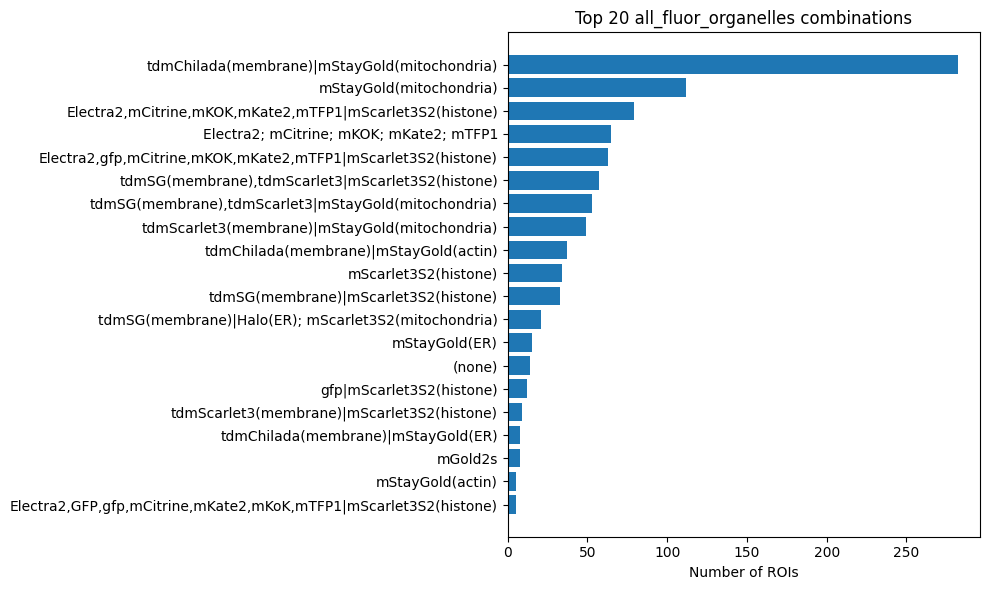

In [97]:
# V3-13 — QC: distribution of all_fluor_organelles combinations

import matplotlib.pyplot as plt

counts_fluor_org = (
    df_full.assign(
        all_fluor_organelles_clean=df_full["all_fluor_organelles"].replace("", "(none)")
    )
    .groupby("all_fluor_organelles_clean", dropna=False)
    .size()
    .reset_index(name="n_rois")
    .sort_values("n_rois", ascending=False)
)

print("Top 30 all_fluor_organelles combinations:")
display(counts_fluor_org.head(30))

top_n = 20
subset = counts_fluor_org.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(subset["all_fluor_organelles_clean"], subset["n_rois"])
plt.gca().invert_yaxis()
plt.xlabel("Number of ROIs")
plt.title(f"Top {top_n} all_fluor_organelles combinations")
plt.tight_layout()
plt.show()

In [98]:
# V3-14 — optional: write v3-labeled copies of the outputs

PATH_ANNOTATIONS_FULL_V3 = WORK / "legacy_imaging_annotations_v3.csv"
PATH_ANNOTATIONS_FOR_DB_V3 = WORK / "2025-11-21-legacy_imaging_annotations_for_db_v3.csv"

df_full.to_csv(PATH_ANNOTATIONS_FULL_V3, index=False)
df_for_db.to_csv(PATH_ANNOTATIONS_FOR_DB_V3, index=False)

print("Also wrote v3 copies:")
print("  full v3:", PATH_ANNOTATIONS_FULL_V3)
print("  for_db v3:", PATH_ANNOTATIONS_FOR_DB_V3)

Also wrote v3 copies:
  full v3: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_annotations_v3.csv
  for_db v3: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/2025-11-21-legacy_imaging_annotations_for_db_v3.csv


In [99]:
# V3-15 — manual review sheet: unique combos + counts and derived metrics (catalog-aware transgenic parents)

import math

review_cols = [
    "parent_female",
    "parent_male",
    "genotype_base_codes",
    "genotype_allele_codes",
    "treatment_plasmid_base_codes",
    "treatment_rna_base_codes",
    "treatment_marker_fusion_labels",
    "genotype_marker_fusion_loc_labels",
    "all_unique_organelles",
    "all_fluor_organelles",
]

missing_review = [c for c in review_cols if c not in df_full.columns]
if missing_review:
    raise ValueError(f"Missing expected columns in df_full: {missing_review}")

def split_pipe(val):
    if val is None:
        return []
    if isinstance(val, float) and math.isnan(val):
        return []
    if not isinstance(val, str):
        val = str(val)
    val = val.strip()
    if not val:
        return []
    if val.lower() == "nan":
        return []
    parts = [x.strip() for x in val.split("|") if x.strip()]
    parts = [x for x in parts if x.lower() != "nan"]
    return parts

df_review = (
    df_full[review_cols]
    .fillna("")
    .groupby(review_cols, dropna=False)
    .size()
    .reset_index(name="n_rows")
    .sort_values("n_rows", ascending=False)
)

PARENT_MAP_PATH = ROOT / "seed_kits" / "legacy_wrangling" / "raw" / "Unique_parent_names__mom_dad_combined__preview_dqm.xlsx"
parent_map = pd.read_excel(PARENT_MAP_PATH)

COL_PARENT_NAME = "parent_fish_name"
COL_PLASMID_BASE = "plasmid_base_code"

required_cols = {COL_PARENT_NAME, COL_PLASMID_BASE}
missing_cols = required_cols - set(parent_map.columns)
if missing_cols:
    raise ValueError(f"Parent-name catalog missing expected columns: {missing_cols}")

parent_is_transgenic = {}
for _, row in parent_map.iterrows():
    name = str(row[COL_PARENT_NAME]).strip()
    plasmid = "" if pd.isna(row[COL_PLASMID_BASE]) else str(row[COL_PLASMID_BASE]).strip()
    parent_is_transgenic[name] = bool(plasmid)

def is_transgenic_parent(name):
    if name is None:
        return False
    name = str(name).strip()
    if not name:
        return False
    return parent_is_transgenic.get(name, False)

def count_transgenic_parents(row):
    pf = row["parent_female"]
    pm = row["parent_male"]
    return int(is_transgenic_parent(pf)) + int(is_transgenic_parent(pm))

def parents_same(row):
    pf = str(row["parent_female"]).strip()
    pm = str(row["parent_male"]).strip()
    if not pf or not pm:
        return False
    return pf == pm

df_review["n_trasngenic_parents"] = df_review.apply(count_transgenic_parents, axis=1)
df_review["are_parents_same"] = df_review.apply(parents_same, axis=1)

df_review["n_genotype_base_codes"] = df_review["genotype_base_codes"].apply(
    lambda s: len(split_pipe(s))
)

df_review["n_treatment_basecodes"] = df_review.apply(
    lambda r: len(
        set(
            split_pipe(r["treatment_plasmid_base_codes"])
            + split_pipe(r["treatment_rna_base_codes"])
        )
    ),
    axis=1,
)

df_review["n_total_base_codes"] = df_review.apply(
    lambda r: len(
        set(
            split_pipe(r["genotype_base_codes"])
            + split_pipe(r["treatment_plasmid_base_codes"])
            + split_pipe(r["treatment_rna_base_codes"])
        )
    ),
    axis=1,
)

df_review["n_total_organelles"] = df_review["all_unique_organelles"].apply(
    lambda s: len(split_pipe(s))
)

ordered_cols = [
    "parent_female",
    "parent_male",
    "genotype_base_codes",
    "genotype_allele_codes",
    "treatment_plasmid_base_codes",
    "treatment_rna_base_codes",
    "n_trasngenic_parents",
    "are_parents_same",
    "n_genotype_base_codes",
    "n_treatment_basecodes",
    "n_total_base_codes",
    "n_total_organelles",
    "treatment_marker_fusion_labels",
    "genotype_marker_fusion_loc_labels",
    "all_unique_organelles",
    "all_fluor_organelles",
    "n_rows",
]

df_review = df_review[ordered_cols]

print("df_review rows (unique combos):", len(df_review))
display(df_review.head(20))

PATH_REVIEW = WORK / "legacy_imaging_combo_summary_v3.csv"
df_review.to_csv(PATH_REVIEW, index=False)
print("Wrote manual-review summary CSV to:", PATH_REVIEW)

df_review rows (unique combos): 45


,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,n_trasngenic_parents,are_parents_same,n_genotype_base_codes,n_treatment_basecodes,n_total_base_codes,n_total_organelles,treatment_marker_fusion_labels,genotype_marker_fusion_loc_labels,all_unique_organelles,all_fluor_organelles,n_rows
29,ef1a:2xLynk:tdmChilada (F1 of allele 315),ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,"pDQM082:315,pDQM082:315",,MGCO-01,2,True,1,1,2,2,mStayGold::2Xcox8A(N),tdmChilada::2xLynk(N)(membrane),membrane|mitochondria,tdmChilada(membrane)|mStayGold(mitochondria),126
1,,,,,"pDQM034,pDQM036",,0,False,0,1,1,0,Electra2; mCitrine; mKOK; mKate2; mTFP1,,,Electra2; mCitrine; mKOK; mKate2; mTFP1,65
17,casper/rnf,ef1a:2xLynk:tdmChilada (F1 of allele 315),,,,MGCO-01,1,False,0,1,1,1,mStayGold::2Xcox8A(N),,mitochondria,mStayGold(mitochondria),60
7,Jim (F2 of allele 316),Ben (F2 of allele 310),"pDQM034,pDQM059","pDQM059:316,pDQM034:310",,pDQM117,2,False,1,1,2,1,mScarlet3S2::H2B(N),"Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1",histone,"Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1|mScarl...",45
3,Ben (F2 of allele 310),Abe (F2 of allele 309),pDQM034,"pDQM034:310,pDQM034:309",,pDQM117,2,False,1,1,2,1,mScarlet3S2::H2B(N),"Electra2,mCitrine,mKOK,mKate2,mTFP1",histone,"Electra2,mCitrine,mKOK,mKate2,mTFP1|mScarlet3S...",40
23,casper/rnf,mem:tdmChilada,pDQM082,pDQM082:315,,MGCO-01,1,False,1,1,2,2,mStayGold::2Xcox8A(N),tdmChilada::2xLynk(N)(membrane),membrane|mitochondria,tdmChilada(membrane)|mStayGold(mitochondria),40
4,Dennis (F2 of allele 318),Abe (F2 of allele 309),"pDQM034,pDQM036","pDQM036:318,pDQM034:309",,pDQM117,2,False,1,1,2,1,mScarlet3S2::H2B(N),"Electra2,mCitrine,mKOK,mKate2,mTFP1",histone,"Electra2,mCitrine,mKOK,mKate2,mTFP1|mScarlet3S...",39
11,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,,MGCO-01,1,False,1,1,2,2,mStayGold::2Xcox8A(N),tdmChilada::2xLynk(N)(membrane),membrane|mitochondria,tdmChilada(membrane)|mStayGold(mitochondria),35
33,ef1a:2xLynk:tdmSG(J) (F1 of allele 302),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:302,pDQM133:324",,pDQM117,2,False,1,1,2,2,mScarlet3S2::H2B(N),"tdmSG::2xLynk(N)(membrane),tdmScarlet3",membrane|histone,"tdmSG(membrane),tdmScarlet3|mScarlet3S2(histone)",33
6,Jim (F2 of allele 316),Abe (F2 of allele 309),,,,pDQM117,2,False,0,1,1,1,mScarlet3S2::H2B(N),,histone,mScarlet3S2(histone),33


Wrote manual-review summary CSV to: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_combo_summary_v3.csv
